# Urban Heat Intelligence - Leuven

This notebook builds an AI pipeline that combines Sentinel-2 satellite imagery with Leuven.cool sensor measurements to predict and analyze urban heat patterns across Leuven.

The project uses multi-year summer data from 2023–2025 and compares several machine learning models.

## Dataset Description

This project combines two datasets:

### Leuven.cool Sensor Data

The Leuven.cool dataset provides ground-based environmental measurements from weather stations across Leuven.

| Column | Description | Usage |
|---|---|---|
| ID | Sensor station identifier | Merge with station metadata |
| TEMPF | Air temperature in Fahrenheit | Converted to Celsius target |
| HUMIDITY | Relative humidity | Environmental feature |
| WINDSPEEDMPH | Wind speed | Environmental feature |
| SOLARRADIATION | Solar radiation | Environmental feature |
| DATEUTC | Timestamp | Temporal matching |
| LATITUDE | Sensor latitude | Spatial matching |
| LONGITUDE | Sensor longitude | Spatial matching |
| ALTITUDE | Station altitude | Environmental feature |

### Sentinel-2 Satellite Data

Sentinel-2 L2A imagery is used to extract environmental features.

| Band | Description | Resolution | Usage |
|---|---|---|---|
| B04 | Red | 10m | NDVI |
| B08 | Near Infrared | 10m | NDVI and NDBI |
| B11 | SWIR | 20m | NDBI |

The analysis focuses on summer Q3 scenes because urban heat effects are strongest during summer.




In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.warp import reproject, Resampling
from pyproj import Transformer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

The Sentinel-2 scenes were selected based on:
- low cloud coverage
- summer availability
- temporal overlap with Leuven.cool measurements

Using multiple years improves the robustness of the AI models and enables temporal analysis of urban heat patterns.

In [13]:
BASE_DIR = Path().resolve().parent

SENTINEL_DIR = BASE_DIR / "data/raw/sentinel2"
LEUVEN_DIR = BASE_DIR / "data/raw/leuven"

SCENES = [
    {"date": "2023-08-10", "year": 2023, "sensor_file": "RAWDATA2023Q3.csv"},
    {"date": "2023-08-20", "year": 2023, "sensor_file": "RAWDATA2023Q3.csv"},
    {"date": "2023-08-23", "year": 2023, "sensor_file": "RAWDATA2023Q3.csv"},
    {"date": "2024-07-30", "year": 2024, "sensor_file": "RAWDATA2024Q3.csv"},
    {"date": "2025-07-02", "year": 2025, "sensor_file": "RAWDATA2025Q3.csv"},
    {"date": "2025-08-11", "year": 2025, "sensor_file": "RAWDATA2025Q3.csv"},
    {"date": "2025-08-12", "year": 2025, "sensor_file": "RAWDATA2025Q3.csv"},
]

To characterize vegetation and urban structures, two environmental indices are computed from Sentinel-2 imagery

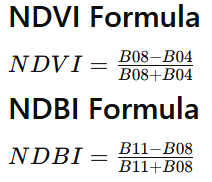

#### Utility Functions

The following helper functions are used to:
- load Sentinel bands
- resample bands with different spatial resolutions
- compute spectral indices
- convert temperature units

Band resampling is necessary because Sentinel-2 bands have different native resolutions.

In [14]:
def load_band(path):
    with rasterio.open(path) as src:
        band = src.read(1).astype(np.float32)
        profile = src.profile
        transform = src.transform
        crs = src.crs

    return band, profile, transform, crs


def resample_to_match(source_path, reference_path):

    with rasterio.open(reference_path) as ref:
        ref_shape = ref.shape
        ref_transform = ref.transform
        ref_crs = ref.crs

    with rasterio.open(source_path) as src:
        source = src.read(1).astype(np.float32)

        destination = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )

    return destination


def compute_index(a, b):
    return (a - b) / (a + b + 1e-6)


def fahrenheit_to_celsius(temp_f):
    return (temp_f - 32) * 5 / 9

Sensor station metadata contains:
- geographic coordinates
- altitude
- station identifiers

These coordinates are required to spatially align sensor measurements with satellite pixels.

In [15]:
stations = pd.read_csv(LEUVEN_DIR / "stations.csv")

stations = stations.rename(columns={
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})

stations.head()

,ID,WOWID,lat,lon,ALTITUDE
0,GARMON01,b1f9850c-d686-e911-80e7-0003ff59889d,50.8710,4.694,21
1,GARMON002,83a89aa6-2695-e911-80e7-0003ff59883f,50.8468,4.756,47
2,GARMON003,2a3596b2-2795-e911-80e7-0003ff59889d,50.8700,4.728,44
3,GARMON004,7d43d8ab-2895-e911-80e7-0003ff59883f,50.8708,4.685,31
4,GARMON005,3f67b310-5597-e911-80e7-0003ff59883f,50.8814,4.713,26


To improve performance, the Leuven.cool datasets are loaded only once and reused throughout the notebook.

In [16]:
sensor_data = {
    2023: pd.read_csv(LEUVEN_DIR / "RAWDATA2023Q3.csv"),
    2024: pd.read_csv(LEUVEN_DIR / "RAWDATA2024Q3.csv"),
    2025: pd.read_csv(LEUVEN_DIR / "RAWDATA2025Q3.csv"),
}

In [5]:
all_rows = []

for scene in SCENES:
    date = scene["date"]
    year = scene["year"]
    sensor_file = scene["sensor_file"]

    print(f"Processing {date}")

    scene_dir = SENTINEL_DIR / date

    b04_path = scene_dir / "B04.jp2"
    b08_path = scene_dir / "B08.jp2"
    b11_path = scene_dir / "B11.jp2"

    red, profile, transform, crs = load_band(b04_path)
    nir, _, _, _ = load_band(b08_path)

    # B11 is 20m, so resample to 10m
    swir = resample_to_match(b11_path, b04_path)

    # Normalize Sentinel reflectance values
    red = red / 10000.0
    nir = nir / 10000.0
    swir = swir / 10000.0

    ndvi = compute_index(nir, red)
    ndbi = compute_index(swir, nir)

    df = pd.read_csv(LEUVEN_DIR / sensor_file)

    df["DATEUTC"] = pd.to_datetime(df["DATEUTC"])
    df["temp_c"] = fahrenheit_to_celsius(df["TEMPF"])

    target_date = pd.to_datetime(date)

    df_day = df[
        (df["DATEUTC"] >= target_date) &
        (df["DATEUTC"] < target_date + pd.Timedelta(days=1))
    ]

    features = [
        "TEMPF",
        "HUMIDITY",
        "WINDSPEEDMPH",
        "SOLARRADIATION"
    ]

    available_features = [col for col in features if col in df_day.columns]

    df_sensor = df_day.groupby("ID")[available_features + ["temp_c"]].mean().reset_index()

    df_sensor = df_sensor.merge(stations, on="ID", how="inner")

    transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)

    for _, row in df_sensor.iterrows():
        lon, lat = row["lon"], row["lat"]
        x, y_coord = transformer.transform(lon, lat)
        col, r = ~transform * (x, y_coord)

        r, col = int(r), int(col)

        if 0 <= r < red.shape[0] and 0 <= col < red.shape[1]:
            all_rows.append({
                "year": year,
                "date": date,
                "ID": row["ID"],
                "lat": lat,
                "lon": lon,
                "altitude": row["ALTITUDE"],
                "humidity": row.get("HUMIDITY", np.nan),
                "wind_speed": row.get("WINDSPEEDMPH", np.nan),
                "solar_radiation": row.get("SOLARRADIATION", np.nan),
                "ndvi": ndvi[r, col],
                "ndbi": ndbi[r, col],
                "temp_c": row["temp_c"]
            })

master_df = pd.DataFrame(all_rows)

master_df.head()

Processing 2023-08-10
Processing 2023-08-20
Processing 2023-08-23
Processing 2024-07-30
Processing 2025-07-02
Processing 2025-08-11
Processing 2025-08-12


,year,date,ID,lat,lon,altitude,humidity,wind_speed,solar_radiation,ndvi,ndbi,temp_c
0,2023,2023-08-10,GARMON002,50.8468,4.756,47,76.572784,0.507047,170.405768,0.563151,-0.239254,18.042966
1,2023,2023-08-10,GARMON003,50.8700,4.728,44,79.112063,0.081443,115.818762,0.493962,-0.168778,17.769959
2,2023,2023-08-10,GARMON004,50.8708,4.685,31,71.898092,0.541314,131.610754,0.450315,-0.139445,18.876866
3,2023,2023-08-10,GARMON005,50.8814,4.713,26,67.366043,0.223049,112.452561,0.149191,0.131995,19.474161
4,2023,2023-08-10,GARMON006,50.9123,4.716,13,72.362313,0.444197,179.573100,0.506226,-0.194784,19.084120


Sensor Data Preprocessing

The sensor datasets are preprocessed by:
- converting timestamps
- converting Fahrenheit to Celsius
- preparing temperature measurements for temporal filtering

In [17]:
for year in sensor_data:

    sensor_data[year]["DATEUTC"] = pd.to_datetime(
        sensor_data[year]["DATEUTC"]
    )

    sensor_data[year]["temp_c"] = fahrenheit_to_celsius(
        sensor_data[year]["TEMPF"]
    )

Multi-Year Feature Extraction Pipeline

For each Sentinel-2 acquisition date:

1. Satellite bands are loaded
2. NDVI and NDBI are computed
3. Sensor measurements are filtered for the corresponding day
4. Geographic coordinates are converted into image coordinates
5. Environmental features are extracted at sensor locations

The final result is a multi-year machine learning dataset for urban heat prediction.

In [18]:
all_rows = []

for scene in SCENES:

    date = scene["date"]
    year = scene["year"]

    print(f"Processing {date}")

    scene_dir = SENTINEL_DIR / date

    b04_path = scene_dir / "B04.jp2"
    b08_path = scene_dir / "B08.jp2"
    b11_path = scene_dir / "B11.jp2"

    # Load bands
    red, profile, transform, crs = load_band(b04_path)
    nir, _, _, _ = load_band(b08_path)

    # Resample SWIR to 10m
    swir = resample_to_match(b11_path, b04_path)

    # Normalize reflectance
    red = red / 10000.0
    nir = nir / 10000.0
    swir = swir / 10000.0

    # Compute indices
    ndvi = compute_index(nir, red)
    ndbi = compute_index(swir, nir)

    # Load correct year data
    df = sensor_data[year]

    target_date = pd.to_datetime(date)

    df_day = df[
        (df["DATEUTC"] >= target_date) &
        (df["DATEUTC"] < target_date + pd.Timedelta(days=1))
    ]

    # Aggregate per station
    df_sensor = df_day.groupby("ID")[
        [
            "temp_c",
            "HUMIDITY",
            "WINDSPEEDMPH",
            "SOLARRADIATION"
        ]
    ].mean().reset_index()

    # Merge coordinates
    df_sensor = df_sensor.merge(
        stations,
        on="ID",
        how="inner"
    )

    # Coordinate transformer
    transformer = Transformer.from_crs(
        "EPSG:4326",
        crs,
        always_xy=True
    )

    # Transform ALL coordinates at once
    xs, ys = transformer.transform(
        df_sensor["lon"].values,
        df_sensor["lat"].values
    )

    cols, rows = ~transform * (xs, ys)

    rows = rows.astype(int)
    cols = cols.astype(int)

    # Keep valid pixels only
    valid = (
        (rows >= 0) &
        (rows < ndvi.shape[0]) &
        (cols >= 0) &
        (cols < ndvi.shape[1])
    )

    df_valid = df_sensor[valid].copy()

    # Extract raster features
    df_valid["ndvi"] = ndvi[
        rows[valid],
        cols[valid]
    ]

    df_valid["ndbi"] = ndbi[
        rows[valid],
        cols[valid]
    ]

    df_valid["year"] = year
    df_valid["date"] = date

    all_rows.append(df_valid)

# Combine everything
master_df = pd.concat(
    all_rows,
    ignore_index=True
)

Processing 2023-08-10
Processing 2023-08-20
Processing 2023-08-23
Processing 2024-07-30
Processing 2025-07-02
Processing 2025-08-11
Processing 2025-08-12


The extracted environmental features are combined into a single structured dataset.

Each row represents:
- one sensor
- one date
- one environmental observation

The dataset now contains:
- satellite-derived indices
- weather variables
- spatial information
- target temperature values

This dataset will be used for:
- machine learning
- deep learning
- model comparison
- urban heat prediction

In [19]:
processed_path = BASE_DIR / "data/processed/master_dataset.csv"

processed_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

master_df.to_csv(
    processed_path,
    index=False
)

print("Dataset shape:", master_df.shape)

master_df.head()

Dataset shape: (633, 13)


,ID,temp_c,HUMIDITY,WINDSPEEDMPH,SOLARRADIATION,WOWID,lat,lon,ALTITUDE,ndvi,ndbi,year,date
0,GARMON002,18.042966,76.572784,0.507047,170.405768,83a89aa6-2695-e911-80e7-0003ff59883f,50.8468,4.756,47,0.563151,-0.239254,2023,2023-08-10
1,GARMON003,17.769959,79.112063,0.081443,115.818762,2a3596b2-2795-e911-80e7-0003ff59889d,50.8700,4.728,44,0.493962,-0.168778,2023,2023-08-10
2,GARMON004,18.876866,71.898092,0.541314,131.610754,7d43d8ab-2895-e911-80e7-0003ff59883f,50.8708,4.685,31,0.450315,-0.139445,2023,2023-08-10
3,GARMON005,19.474161,67.366043,0.223049,112.452561,3f67b310-5597-e911-80e7-0003ff59883f,50.8814,4.713,26,0.149191,0.131995,2023,2023-08-10
4,GARMON006,19.084120,72.362313,0.444197,179.573100,a4378238-ea95-e911-80e7-0003ff59889d,50.9123,4.716,13,0.506226,-0.194784,2023,2023-08-10
